# PL player value predictor: exploration and experiments

This notebook walks through the data, the model, and the experiments behind the
choices in `src/`. It is meant to be read top to bottom, and every result is
recomputed from the code in the repo, so it stays honest as the pipeline changes.

**Before running:** build the dataset with `python -m src.data.build_dataset`
(needs the API key in `.env`; see the README).

Contents:
1. The data
2. What drives market value
3. The model and how well it does
4. Experiment log: what helped, what didn't
5. Who does the model think is over- or under-valued?

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import PROCESSED_DATASET_PATH
from src.features import CATEGORICAL_FEATURES, NUMERIC_FEATURES, add_derived_features
from src.model import build_pipeline, cross_validate_model, fit_pipeline, value_weights

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

raw = pd.read_csv(PROCESSED_DATASET_PATH)
df = add_derived_features(raw)
print(f"{len(df)} players, {df.club.nunique()} clubs")

540 players, 20 clubs


## 1. The data

One row per player in a current Premier League squad. Three sources are joined by name:

| Source | Gives us |
|---|---|
| Transfermarkt (scraped) | market value (the target), age, position, club |
| football-data.org | goals, assists, penalties, appearances, summed over 2023–2025 (scorers only) |
| Fantasy Premier League API | this season's minutes and starts (plus xG/xA, defensive stats, which we don't use yet) |

In [2]:
raw.head(8)

,name,position,age,nationality,club,market_value_eur,goals,assists,penalties,appearances,has_scorer_record,fpl_minutes,fpl_starts,fpl_xg,fpl_xa,fpl_defensive_contribution,fpl_price,fpl_gameweeks,has_fpl_record
0,David Raya,Goalkeeper,31,Spain,Arsenal FC,30000000.0,0,0,0,0,0,450,5,0.00,0.01,0,6.0,4,1
1,Illan Meslier,Goalkeeper,26,France,Arsenal FC,8000000.0,0,0,0,0,0,0,0,0.00,0.00,0,4.9,4,1
2,Kepa Arrizabalaga,Goalkeeper,31,Spain,Arsenal FC,5000000.0,0,0,0,0,0,0,0,0.00,0.00,0,4.9,4,1
3,William Saliba,Centre-Back,25,France,Arsenal FC,100000000.0,5,1,0,104,1,0,0,0.00,0.00,0,5.9,4,1
4,Gabriel,Centre-Back,28,Brazil,Arsenal FC,75000000.0,0,0,0,0,0,450,5,0.51,0.20,41,8.0,4,1
5,Piero Hincapié,Centre-Back,24,Ecuador,Arsenal FC,50000000.0,1,2,0,30,1,32,0,0.00,0.00,3,5.3,4,1
6,Ezri Konsa,Centre-Back,28,England,Arsenal FC,45000000.0,3,0,0,70,1,281,3,0.23,0.02,23,4.6,4,1
7,Cristhian Mosquera,Centre-Back,22,Spain,Arsenal FC,40000000.0,0,0,0,0,0,168,2,0.00,0.01,10,5.3,4,1


### Coverage matters more than it looks

football-data.org only lists players with a goal or assist, so most defenders and
keepers have *no* stats rather than zero stats. The model gets a `has_scorer_record`
flag so it can tell "no data" from "played and didn't score".

In [3]:
coverage = pd.DataFrame(
    {
        "players with football-data.org stats": raw.has_scorer_record.mean(),
        "players with FPL record": raw.has_fpl_record.mean(),
        "FPL players with minutes > 0": (raw.fpl_minutes > 0).mean(),
    },
    index=["share of dataset"],
).T
coverage.style.format("{:.0%}")

,share of dataset
players with football-data.org stats,51%
players with FPL record,96%
FPL players with minutes > 0,74%


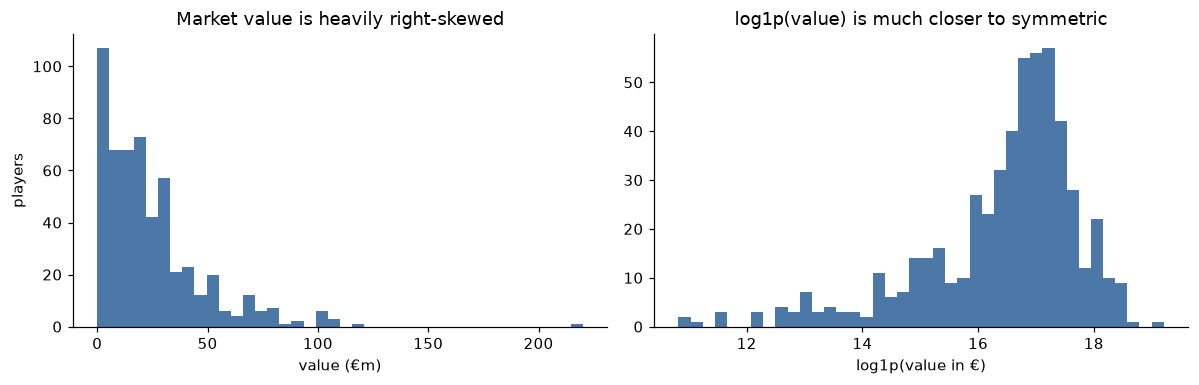

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(df.market_value_eur / 1e6, bins=40, color="#4c78a8")
axes[0].set(title="Market value is heavily right-skewed", xlabel="value (€m)", ylabel="players")
axes[1].hist(np.log1p(df.market_value_eur), bins=40, color="#4c78a8")
axes[1].set(title="log1p(value) is much closer to symmetric", xlabel="log1p(value in €)")
fig.tight_layout()

The skew is why the target is `log1p(value)`. A side effect: the model minimises *relative*
error, which matters in section 4.

## 2. What drives market value

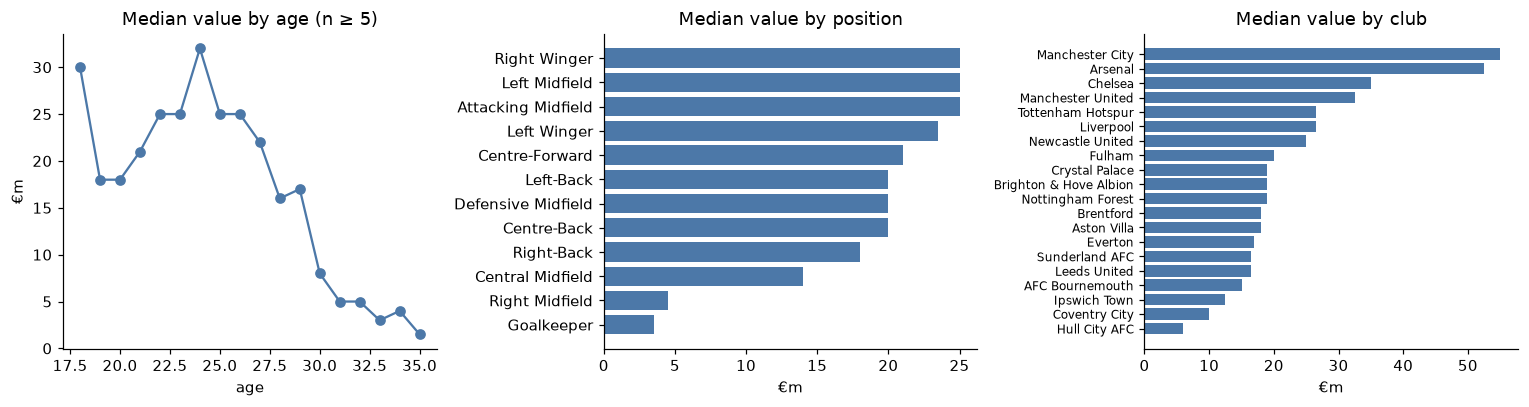

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

by_age = df.groupby("age").market_value_eur.agg(["median", "size"])
by_age = by_age[by_age["size"] >= 5]
axes[0].plot(by_age.index, by_age["median"] / 1e6, "o-", color="#4c78a8")
axes[0].set(title="Median value by age (n ≥ 5)", xlabel="age", ylabel="€m")

order = df.groupby("position").market_value_eur.median().sort_values()
axes[1].barh(order.index, order / 1e6, color="#4c78a8")
axes[1].set(title="Median value by position", xlabel="€m")

order = df.groupby("club").market_value_eur.median().sort_values()
axes[2].barh([c.replace(" FC", "") for c in order.index], order / 1e6, color="#4c78a8")
axes[2].set(title="Median value by club", xlabel="€m")
axes[2].tick_params(axis="y", labelsize=8)
fig.tight_layout()

Value peaks in the mid-20s and falls either side, so a straight line in age is the wrong
shape. That's why the model has `age_squared`. Club matters a lot too, since the same
player is worth more at a bigger club.

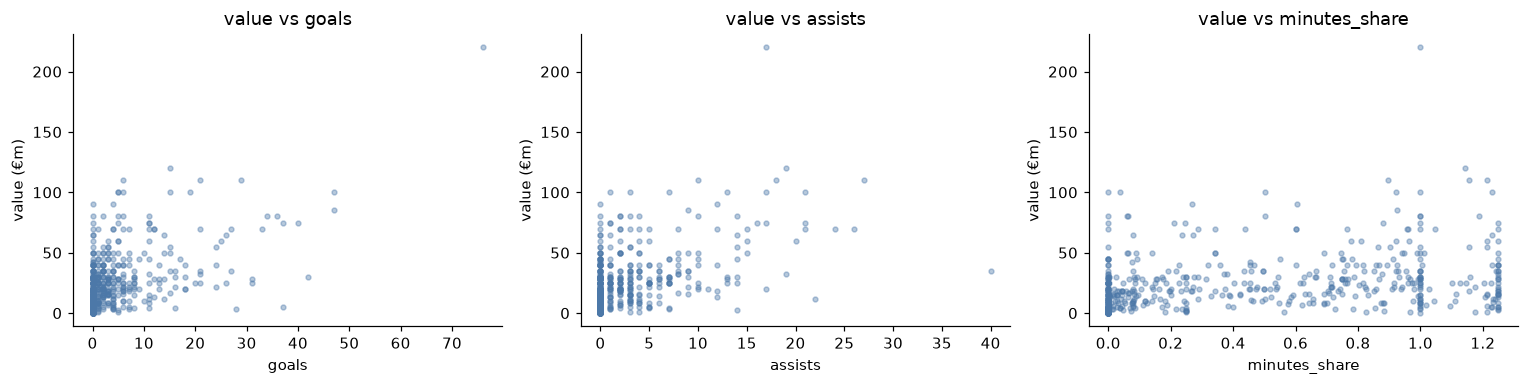

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col in zip(axes, ["goals", "assists", "minutes_share"]):
    ax.scatter(df[col], df.market_value_eur / 1e6, s=10, alpha=0.4, color="#4c78a8")
    ax.set(xlabel=col, ylabel="value (€m)", title=f"value vs {col}")
fig.tight_layout()

Goals and assists only matter for the few players who have them (most of the dataset sits at
zero). `minutes_share`, this season's minutes as a fraction of what was available,
separates regulars from squad players across *all* positions, which is why it turned out to
be the most useful addition.

## 3. The model and how well it does

In [7]:
print("Numeric features:    ", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print()
print("Pipeline: StandardScaler on numeric + one-hot on categorical -> LinearRegression")

Numeric features:     ['age', 'age_squared', 'goals', 'assists', 'penalties', 'appearances', 'has_scorer_record', 'has_fpl_record', 'minutes_share', 'starts_share']
Categorical features: ['position', 'club']

Pipeline: StandardScaler on numeric + one-hot on categorical -> LinearRegression


In [8]:
metrics = cross_validate_model(df)
pd.Series(
    {
        "R² (log value)": f"{metrics['cv_r2_log']:.3f}",
        "MAE": f"€{metrics['cv_mae_eur'] / 1e6:.1f}m",
        "RMSE": f"€{metrics['cv_rmse_eur'] / 1e6:.1f}m",
        "MAE, top 10% most valuable": f"€{metrics['cv_top_decile_mae_eur'] / 1e6:.1f}m",
        "predicted/actual, top 10%": f"{metrics['cv_top_decile_ratio']:.2f}  (1.0 = unbiased)",
    },
    name="5-fold cross-validation",
).to_frame()

,5-fold cross-validation
R² (log value),0.581
MAE,€9.3m
RMSE,€13.5m
"MAE, top 10% most valuable",€24.7m
"predicted/actual, top 10%",0.84 (1.0 = unbiased)


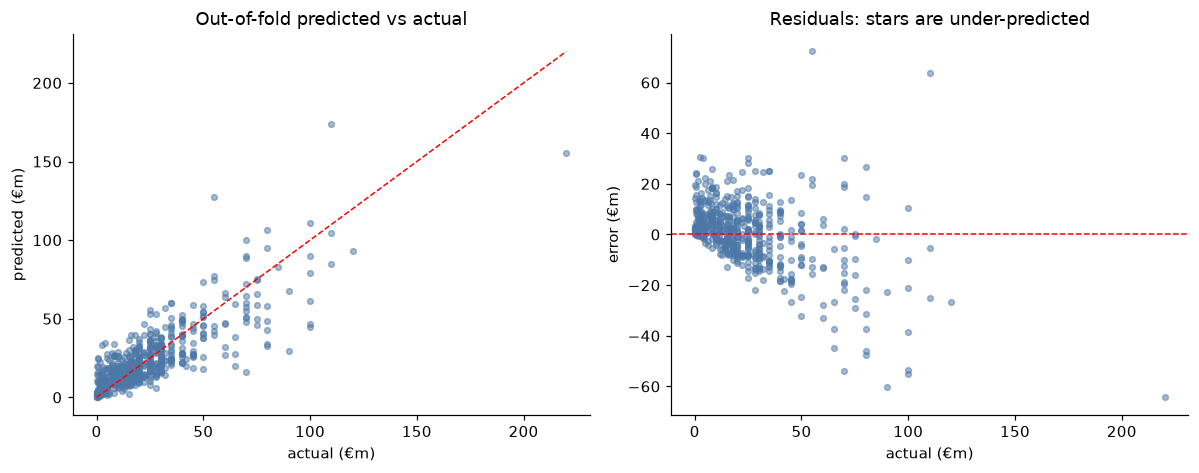

In [9]:
# Out-of-fold predictions: every player is predicted by a model that never saw them.
from sklearn.model_selection import KFold

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = np.log1p(df.market_value_eur)
oof = pd.Series(0.0, index=df.index)
for tr, te in KFold(5, shuffle=True, random_state=42).split(X):
    oof.iloc[te] = fit_pipeline(build_pipeline(), X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
df["predicted_eur"] = np.expm1(oof)
df["error_eur"] = df.predicted_eur - df.market_value_eur

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(df.market_value_eur / 1e6, df.predicted_eur / 1e6, s=14, alpha=0.5, color="#4c78a8")
lim = df.market_value_eur.max() / 1e6
axes[0].plot([0, lim], [0, lim], "r--", lw=1)
axes[0].set(xlabel="actual (€m)", ylabel="predicted (€m)", title="Out-of-fold predicted vs actual")
axes[1].scatter(df.market_value_eur / 1e6, df.error_eur / 1e6, s=14, alpha=0.5, color="#4c78a8")
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set(xlabel="actual (€m)", ylabel="error (€m)", title="Residuals: stars are under-predicted")
fig.tight_layout()

The fan shape on the right is the model's main weakness: the more valuable the player,
the more it under-predicts. Regression to the mean explains part of it. The rest is
"star premium" that on-pitch stats in this dataset simply don't capture.

## 4. Experiment log

Everything below is cross-validated (5 folds × 3 repeats), because a single 80/20 split at
this dataset size swings by ~0.1 R². The harness re-fits the pipeline from scratch each fold.

In [10]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

gw = df.fpl_gameweeks.clip(lower=1)
df["xgi_per_gw"] = (df.fpl_xg + df.fpl_xa) / gw
df["def_per_gw"] = df.fpl_defensive_contribution / gw

values = df.market_value_eur.to_numpy()
y_log = np.log1p(values)
top = values >= np.quantile(values, 0.9)


def cv_eval(numeric, regressor=None, weighted=True, categorical=CATEGORICAL_FEATURES,
            n_repeats=3, target_power=None):
    """Repeated K-fold; returns mean log-R², euro MAE, top-decile MAE and ratio."""
    rows = []
    cv = RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=0)
    for tr, te in cv.split(df):
        pre = ColumnTransformer([
            ("n", StandardScaler(), numeric),
            ("c", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical),
        ])
        pipe = Pipeline([("p", pre), ("r", clone(regressor) if regressor is not None else LinearRegression())])
        cols = numeric + categorical
        fit_kw = {"r__sample_weight": value_weights(values[tr])} if weighted else {}
        pipe.fit(df.iloc[tr][cols], y_log[tr], **fit_kw)
        pred = np.expm1(pipe.predict(df.iloc[te][cols]))
        err = np.abs(pred - values[te])
        t = top[te]
        rows.append([
            1 - ((np.log1p(pred) - y_log[te]) ** 2).sum() / ((y_log[te] - y_log[te].mean()) ** 2).sum(),
            err.mean() / 1e6,
            err[t].mean() / 1e6,
            (pred[t] / values[te][t]).mean(),
        ])
    r = np.nanmean(rows, axis=0)
    return {"R² (log)": r[0], "MAE €m": r[1], "top-10% MAE €m": r[2], "top-10% pred/actual": r[3]}


def table(results):
    return pd.DataFrame(results).T.style.format(
        {"R² (log)": "{:.3f}", "MAE €m": "{:.2f}", "top-10% MAE €m": "{:.1f}", "top-10% pred/actual": "{:.2f}"}
    ).background_gradient(subset=["MAE €m"], cmap="RdYlGn_r")

### 4a. Feature engineering (linear regression, sqrt-value weighting)

In [11]:
base = ["age", "goals", "assists", "penalties", "appearances"]
sets = {
    "1. raw stats only": base,
    "2. + age² (value peaks mid-20s)": base + ["age_squared"],
    "3. + has_scorer_record": base + ["age_squared", "has_scorer_record"],
    "4. + FPL playing time (current model)": base + ["age_squared", "has_scorer_record",
                                                     "has_fpl_record", "minutes_share", "starts_share"],
    "5. + FPL xG/xA per gameweek": NUMERIC_FEATURES + ["xgi_per_gw"],
    "6. + FPL defensive contribution": NUMERIC_FEATURES + ["xgi_per_gw", "def_per_gw"],
    "7. + FPL price (rejected, see below)": NUMERIC_FEATURES + ["fpl_price"],
}
table({name: cv_eval(cols) for name, cols in sets.items()})

,R² (log),MAE €m,top-10% MAE €m,top-10% pred/actual
1. raw stats only,0.361,11.46,27.2,0.77
2. + age² (value peaks mid-20s),0.499,10.03,26.8,0.81
3. + has_scorer_record,0.508,9.93,26.0,0.81
4. + FPL playing time (current model),0.581,9.31,25.2,0.86
5. + FPL xG/xA per gameweek,0.582,9.35,25.8,0.86
6. + FPL defensive contribution,0.586,9.43,26.6,0.87
"7. + FPL price (rejected, see below)",0.610,11.11,49.8,0.99


What to take from this:

- **Age² and playing time are the two real wins.** Age² fixes the wrong-shaped age curve;
  `minutes_share`/`starts_share` tell the model who actually plays.
- **xG/xA and defensive stats add nothing yet.** Only 4 gameweeks are in, so they're mostly
  noise. Worth re-testing later in the season.
- **`fpl_price` is rejected.** It lifts log-R² but *worsens* euro error, especially for stars
  (its range is compressed, and it's FPL's own valuation rather than performance).

### 4b. Does a fancier model help?

In [12]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

def rf():
    return RandomForestRegressor(300, min_samples_leaf=3, random_state=0, n_jobs=-1)

def gb():
    return GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05,
                                     subsample=0.8, random_state=0)

cur = NUMERIC_FEATURES
table({
    "Linear, √value weights (current)": cv_eval(cur, n_repeats=2),
    "Linear, unweighted": cv_eval(cur, weighted=False, n_repeats=2),
    "Random forest, √value weights": cv_eval(cur, rf(), n_repeats=2),
    "Random forest, unweighted": cv_eval(cur, rf(), weighted=False, n_repeats=2),
    "Gradient boosting, √value weights": cv_eval(cur, gb(), n_repeats=2),
    "Gradient boosting, unweighted": cv_eval(cur, gb(), weighted=False, n_repeats=2),
})

,R² (log),MAE €m,top-10% MAE €m,top-10% pred/actual
"Linear, √value weights (current)",0.584,9.27,25.0,0.85
"Linear, unweighted",0.626,9.78,28.6,0.87
"Random forest, √value weights",0.520,10.28,33.3,0.64
"Random forest, unweighted",0.585,10.31,37.1,0.57
"Gradient boosting, √value weights",0.582,9.50,29.1,0.73
"Gradient boosting, unweighted",0.632,9.41,30.6,0.67


Every model gets the same features and the same choice of weighting. What to take from this:

- **Linear with √value weights has the lowest euro error**, both overall and for the top 10%.
- **Gradient boosting ties the linear model on log-R² only when both are unweighted**
  (~0.63), and is much more conservative on stars (pred/actual ≈ 0.7 vs ≈ 0.85).
- **Random forest is worst throughout.**

With ~540 rows the extra flexibility of trees isn't buying anything on the metric we care about,
so the simple, explainable model stays. Gradient boosting is the one to revisit if the dataset
grows (e.g. multi-season data).

### 4c. The star-player problem

Plain log-value regression treats a 10% error on a €1m player the same as on a €100m
player, so the many cheap players outvote the few stars. Weighting each player by
√value in training rebalances that:

In [13]:
table({
    "unweighted": cv_eval(NUMERIC_FEATURES, weighted=False),
    "weight ∝ √value (current)": cv_eval(NUMERIC_FEATURES),
})

,R² (log),MAE €m,top-10% MAE €m,top-10% pred/actual
unweighted,0.624,9.86,29.0,0.89
weight ∝ √value (current),0.581,9.31,25.2,0.86


Weighting cuts euro error both overall (€9.9m → €9.3m) and on the top 10% (€29m → €25m). It's a
trade-off, not a free win: log-R² drops (0.62 → 0.58), and the average top-10% pred/actual
ratio is actually slightly *better* unweighted (0.89 vs 0.86). We optimise the euro error
because that's what "how far off is the estimate" means to a user.

The model is still conservative about the very top. Removing that bias with a smearing correction
made the *overall* error worse in earlier experiments (€10.3m → €11.6m), so it's not adopted. The
remaining gap is probably a data problem (no brand/contract/transfer information), not a modelling one.

## 5. Who does the model think is over- or under-valued?

Out-of-fold predictions (section 3), so each player is scored by a model that never saw them.
A large gap doesn't mean Transfermarkt is *wrong*. It means the player is worth more (or
less) than their on-pitch numbers and profile alone would suggest, e.g. a hyped youngster, or
a defender whose value is in things these stats don't measure.

**Read the "FPL data" column.** A 0 means the player wasn't found in the FPL data (usually a
loanee or someone who's left), so the model has no playing-time information and treats them
like a bench player, which under-predicts them. Some of the biggest "worth less" gaps below
are this artefact, not a real signal.

In [14]:
cols = ["name", "club", "position", "age", "has_fpl_record", "market_value_eur", "predicted_eur"]
gap = df[cols].assign(gap_pct=(df.predicted_eur / df.market_value_eur - 1) * 100)
big = gap[gap.market_value_eur >= 15e6]  # ignore tiny values, where % gaps are meaningless

def show(frame):
    return frame.assign(
        market_value_eur=(frame.market_value_eur / 1e6).round(1),
        predicted_eur=(frame.predicted_eur / 1e6).round(1),
        gap_pct=frame.gap_pct.round(0),
    ).rename(columns={"market_value_eur": "actual €m", "predicted_eur": "predicted €m",
                      "gap_pct": "gap %", "has_fpl_record": "FPL data"}
    ).reset_index(drop=True)

print("Model thinks these are worth MORE than Transfermarkt says (players ≥ €15m):")
display(show(big.sort_values("gap_pct", ascending=False).head(10)))
print("Model thinks these are worth LESS:")
display(show(big.sort_values("gap_pct").head(10)))

Model thinks these are worth MORE than Transfermarkt says (players ≥ €15m):


,name,club,position,age,FPL data,actual €m,predicted €m,gap %
0,Vitaly Janelt,Brentford FC,Defensive Midfield,28,1,16.0,39.4,146.0
1,Antonín Kinský,Tottenham Hotspur FC,Goalkeeper,23,1,15.0,36.2,141.0
2,Kai Havertz,Arsenal FC,Centre-Forward,27,1,55.0,127.3,131.0
3,Lewis Miley,Newcastle United FC,Central Midfield,20,1,25.0,55.4,121.0
4,James McAtee,Nottingham Forest FC,Attacking Midfield,23,1,18.0,39.6,120.0
5,Josh Acheampong,Chelsea FC,Centre-Back,20,1,25.0,53.3,113.0
6,Roméo Lavia,Chelsea FC,Defensive Midfield,22,1,22.0,46.5,111.0
7,Jair Cunha,Nottingham Forest FC,Centre-Back,21,1,15.0,30.0,100.0
8,Rico Lewis,Manchester City FC,Right-Back,21,1,28.0,52.9,89.0
9,Dejan Kulusevski,Tottenham Hotspur FC,Attacking Midfield,26,1,17.0,31.9,87.0


Model thinks these are worth LESS:


,name,club,position,age,FPL data,actual €m,predicted €m,gap %
0,Alisson,Liverpool FC,Goalkeeper,33,0,15.0,2.2,-85.0
1,Djordje Petrovic,AFC Bournemouth,Goalkeeper,26,0,28.0,6.1,-78.0
2,Junior Kroupi,AFC Bournemouth,Centre-Forward,20,1,70.0,16.0,-77.0
3,Johan Manzambi,Aston Villa FC,Attacking Midfield,20,1,65.0,20.0,-69.0
4,Christos Mouzakitis,Hull City AFC,Central Midfield,19,1,25.0,7.9,-69.0
5,Bradley Barcola,Liverpool FC,Left Winger,24,1,90.0,29.6,-67.0
6,Bazoumana Touré,Newcastle United FC,Left Winger,20,1,50.0,17.9,-64.0
7,Estêvão,Chelsea FC,Right Winger,19,1,80.0,32.4,-60.0
8,Ismaïla Sarr,Crystal Palace FC,Right Winger,28,1,45.0,18.4,-59.0
9,Joelinton,Newcastle United FC,Central Midfield,30,1,25.0,10.6,-58.0


## Where to go next

- **Re-test xG/xA and defensive stats** as more gameweeks are played (they may start to help).
- **Historical FPL / Understat data** would give minutes and xG over several seasons, not just
  the current one.
- **Contract length and transfer history** (e.g. the Transfermarkt datasets on Kaggle) are the most
  likely source of the missing "star premium".